# Summaries

## Part 1 Summary

Part One of *Practical Deep Learning for Coders* spans nine lessons (including an optional Lesson Zero) and takes a deliberate, top-down approach: you train a state-of-the-art model in the very first session, then spend the remaining lessons peeling back the layers to understand why it works. The pedagogy draws explicitly on Paul Lockhart and David Perkins — show the whole game first, then build skills — and the recurring message is almost comically blunt: finish the course, finish a project, be tenacious, stop endlessly preparing.

Lesson Zero sets the tone by confronting the habits that derail most learners. Jeremy presents YouTube analytics showing steep drop-off curves and urges you to schedule specific days for watching and for assignments. The story of Christine McLeavey — a fast.ai alumna who built a deep-learning music composition system that the BBC eventually performed — illustrates the power of polishing one great project rather than accumulating half-finished ones. Radek Osmulski, a non-degree-holding former corporate worker who failed repeatedly before winning a Kaggle competition, embodies the tenacity theme. The four-step study method is laid out: watch the lecture, run the notebook and experiment, reproduce results from scratch, then repeat with a different dataset. Practical tooling advice follows — notebook servers, the "clean" notebook versions for active recall, git, SSH, blogging — all in service of the principle that building and sharing a portfolio is how you get a job in this field.

Lesson 1 demolishes the idea that deep learning requires vast resources. An xkcd comic from 2015 joked that bird recognition would require a research team and five years; Jeremy downloads 200 bird photos and 200 forest photos, trains a classifier on a laptop while streaming video, and achieves near-perfect accuracy in under 30 seconds. The lesson surveys what deep learning can do — DALL·E 2 generating art from text prompts, PaLM answering questions with chain-of-thought reasoning — then introduces the core abstractions: DataBlock, DataLoaders, Learner, and fine-tuning a pre-trained ResNet. Image classification, segmentation, tabular prediction, and collaborative filtering are all demonstrated in the same pattern: load data, create a learner, train, inspect. The Zeiler and Fergus visualizations show what CNNs learn layer by layer — edges, corners, textures, object parts — without any hand-engineering. Arthur Samuel's training loop (inputs + weights → predictions → loss → update weights → repeat) is presented as the conceptual skeleton of all machine learning.

Lesson 2 pivots to deployment. The central insight is counterintuitive: train a model *before* cleaning your data, because the model's mistakes reveal your data's problems more efficiently than manual inspection. Resizing strategies are compared — squish, crop, pad, and the preferred RandomResizedCrop — and data augmentation via `aug_transforms` is introduced. The confusion matrix and `plot_top_losses` surface the images where the model is most wrong, feeding directly into `ImageClassifierCleaner`. Deployment uses HuggingFace Spaces with Gradio: a minimal three-line app goes live within a minute. The trained model is exported as a pickle file (the only step requiring a GPU), and a JavaScript front-end calling the Spaces API demonstrates that a single model can power multiple interfaces.

Lesson 3 digs into the mathematical foundations. Starting with a quadratic function and Jupyter's `@interact` sliders, Jeremy demonstrates fitting a curve by hand, then automates it with gradient descent — PyTorch's `requires_grad_()`, `.backward()`, and a learning-rate-scaled parameter update. The Rectified Linear Unit (ReLU) is the key insight: a single ReLU is just a line clipped at zero, but summing enough ReLUs with different slopes and offsets can approximate any function to arbitrary precision. This is genuinely the entirety of deep learning's representational power. The lesson culminates in building a complete model in an Excel spreadsheet on the Titanic dataset — linear regression via SUMPRODUCT, a neural network via ReLU applied to a hidden layer, and matrix multiplication via MMULT — demonstrating that the critical operation in all of deep learning is multiplying things together and adding them up.

Lesson 4 introduces Natural Language Processing using HuggingFace Transformers rather than fastai, deliberately stepping to a lower-level API so the same concepts are seen from a different angle. The story of ULMFiT — the transfer-learning recipe Jeremy co-authored — explains the three-stage pipeline: pre-train a language model, fine-tune on domain text, then fine-tune for classification. Tokenization is covered in detail (sub-word units, not full words). A substantial portion addresses overfitting, underfitting, and validation: polynomial fits show what underfitting and overfitting look like visually, and the lesson stresses that a good validation set is not a random split — for time series you hold out the most recent dates, for people-based tasks you hold out entire people. Metrics are distinguished from loss functions (accuracy has zero gradient almost everywhere; Pearson correlation is explored visually at different levels). The practical project is the U.S. Patent Phrase Matching Kaggle competition, where `deberta-v3-small` reaches r ≈ 0.834 after about 20 minutes of training. The lesson closes with a serious discussion of NLP's misuse potential — GPT-generated fake comments, bot-written op-eds — and the argument that broad understanding is the best defense.

Lesson 5 builds a complete model from scratch in Python and PyTorch on the Titanic dataset. Missing values are imputed with the mode, skewed fare data is log-transformed, and categorical columns become dummy variables. Broadcasting — the APL-derived mechanism that lets a vector multiply across all rows of a matrix in one operation — is introduced. A linear model is trained with gradient descent, sigmoid is applied for binary targets, and the result is submitted to Kaggle at the 50th percentile. A single-hidden-layer neural network and then a deep (multi-layer) network are built by simply adding more weight matrices and ReLUs. The lesson then shows why you'd use a framework in practice: fastai's `TabularPandas` handles all preprocessing, `lr_find()` automates learning rate selection, and ensembling five models with different random seeds pushes the submission from the 50th to the top 25th percentile. The final act introduces random forests from first principles — a binary split divides passengers into groups with different survival rates, scored by weighted standard deviation.

Lesson 6 extends binary splits into full decision trees and then into random forests. Gini impurity is explained as the split-quality metric. The theoretical foundation of bagging is laid out: averaging many trees built on random subsets produces uncorrelated, unbiased predictions whose errors cancel. Feature importance — summing Gini improvements per column across all trees — is demonstrated, and Jeremy recounts using it to identify 30 useful columns from 7,000 in a credit-scoring dataset. Out-of-bag error, partial dependence plots, and gradient boosting are all covered. The second half shifts to the Paddy Disease Classification Kaggle competition, demonstrating an iterative workflow: start with the fastest model, submit immediately, iterate. Test Time Augmentation (TTA) averages predictions over multiple augmented versions of each test image. The lesson embodies the principle that modeling should be fast and hypothesis-driven, not an exhaustive grid search.

Lesson 7 tackles GPU memory constraints head-on with gradient accumulation — processing smaller batches but accumulating gradients before updating, which is mathematically equivalent to the original large batch but fits in less memory. An ensemble of large models (ConvNeXt, ViT, Swin, SwinV2) with TTA reaches the top of the Kaggle leaderboard. Multi-target models — predicting both disease and rice variety from one image — lead into a thorough explanation of cross-entropy loss (softmax converts raw outputs to probabilities; cross-entropy penalizes low probability on the correct class). Collaborative filtering is then introduced through the MovieLens dataset: users and movies each get a vector of latent factors, ratings are predicted by dot product, and gradient descent optimizes the factors. An embedding is revealed to be nothing more than an array lookup — computationally equivalent to multiplying by a one-hot vector. Bias terms capture per-user and per-movie tendencies, and weight decay (L2 regularization) is introduced to combat overfitting.

Lesson 8, the Part One finale, rebuilds embeddings from scratch using `nn.Parameter`, then interprets the trained collaborative filtering model: sorting movie biases reveals universally loved and disliked films, and PCA on the latent factors produces a two-dimensional map where one axis separates blockbusters from critically acclaimed films and the other separates action from drama — all discovered by SGD with no genre labels. Tabular deep learning is demonstrated on the bulldozer auction dataset using entity embeddings for categorical variables, and the Guo and Berkhahn paper is cited: their trained region embeddings reproduced Germany's geography without location data. Convolutions are explained in an Excel spreadsheet — a 3×3 kernel slides across an image computing dot products, and edge-detecting kernels emerge as learned features. Stride-2 convolutions replace max pooling for spatial reduction, and fast.ai's concat pooling combines max and average pooling. Dropout — randomly zeroing activations during training — is presented as data augmentation for the network's internals, forcing robust feature learning. The lesson closes with an extended AMA covering motivation, the myth that bigger models are always necessary, and Jeremy's productivity philosophy: spend half your time learning, don't overwork, get good sleep, and finish things properly.

---

**Lesson Challenges**

- Train a cat-vs-dog classifier; try three or four custom categories (Lesson 1)
- Build and deploy your own image classifier on HuggingFace Spaces with Gradio (Lesson 2)
- Create a JavaScript front-end calling your model's API (Lesson 2)
- Reproduce the quadratic-fitting and ReLU demonstrations (Lesson 3)
- Recreate the Titanic neural network in a spreadsheet or from scratch in Python (Lesson 3)
- Improve the Pearson correlation on the Patent Phrase Matching competition (Lesson 4)
- Build a linear model, neural net, and deep learning model from scratch on Titanic (Lesson 5)
- Build a Random Forest from scratch and implement feature importance (Lesson 6)
- Enter the Paddy Disease Classification Kaggle competition and iterate (Lesson 6)
- Experiment with gradient accumulation, multi-target models, and cross-entropy (Lesson 7)
- Rebuild the embedding module from scratch using `nn.Parameter` (Lesson 8)
- Trace the convolution and dropout Excel spreadsheets (Lesson 8)

**Potential Research Directions**

- Transfer learning effectiveness with very small datasets (<50 items)
- Converting non-image data (sound, time series, mouse movements) into images for classification
- How validation set design affects model reliability across domains
- ULMFiT vs. Transformer approaches for long-document classification
- Robust detection methods for AI-generated text at scale
- The OneR paper and when the simplest model is competitive
- Broadcasting semantics and their origin in APL / Ken Iverson's notation
- Leo Breiman's "Statistical Modeling: The Two Cultures"
- Partial dependence plots for deep learning models
- Multi-target learning's effect on single-target accuracy
- Entity embeddings of categorical variables in non-deep-learning models (Guo & Berkhahn)
- The cold-start / bootstrapping problem in recommendation systems
- Convolution as constrained matrix multiplication and its implications for architecture design

**Homework**

- Set up a GPU environment (Colab, Kaggle, Paperspace Gradient) and run the Chapter 1 notebook (Lesson 0)
- Reproduce Chapter 1 results from scratch in a blank notebook (Lesson 0)
- Read Chapters 1, 2, 4, 8, 9, 10, and 13 of the [fastbook](https://github.com/fastai/fastbook)
- Read [*Python for Data Analysis*](https://wesmckinney.com/book/) by Wes McKinney
- Work through the Kaggle notebooks: [Is it a bird?](https://www.kaggle.com/code/jhoward/is-it-a-bird-creating-a-model-from-your-own-data), [How does a neural net really work?](https://www.kaggle.com/code/jhoward/how-does-a-neural-net-really-work), [NLP for absolute beginners](https://www.kaggle.com/code/jhoward/getting-started-with-nlp-for-absolute-beginners), [Linear model and neural net from scratch](https://www.kaggle.com/code/jhoward/linear-model-and-neural-net-from-scratch), [How random forests really work](https://www.kaggle.com/code/jhoward/how-random-forests-really-work/), [Road to the Top Parts 1–4](https://www.kaggle.com/code/jhoward/first-steps-road-to-the-top-part-1), [Collaborative filtering deep dive](https://www.kaggle.com/code/jhoward/collaborative-filtering-deep-dive/notebook)
- Submit to Kaggle competitions: [Titanic](https://www.kaggle.com/competitions/titanic), [U.S. Patent Phrase Matching](https://www.kaggle.com/competitions/us-patent-phrase-to-phrase-matching), [Paddy Disease Classification](https://www.kaggle.com/competitions/paddy-disease-classification)
- Experiment with the Excel spreadsheets: [softmax/cross-entropy](https://github.com/fastai/course22/blob/master/xl/entropy_example.xlsx), [collaborative filtering](https://github.com/fastai/course22/blob/master/xl/collab_filter.xlsx), [convolutions](https://github.com/fastai/course22/blob/master/xl/conv-example.xlsx)
- Start a blog and share your work on the [fast.ai forums](https://forums.fast.ai/t/share-your-work-here/96015)

**Things Jeremy Says You Should Do**

- Finish the damn course — schedule it, tell someone, commit
- Finish a project — one polished project beats ten half-finished ones
- Be tenacious — keep going after setbacks, even if resuming takes a year
- Stop endlessly preparing — train a model in Week One
- Use the clean notebooks and chapter questionnaires for active recall
- Start with a simple baseline for every project
- Always train a model before cleaning your data
- Use RandomResizedCrop and aug_transforms for training beyond ~5 epochs
- Watch each lecture through once, then rewatch while running the notebook
- Join or create a study group
- Always use a validation set; think carefully about how to construct it
- Always look at your data and your model's outputs — visualize everything
- Never throw away data — impute, don't drop
- For binary targets, always apply sigmoid as the final activation
- Start every tabular project with a Random Forest
- Submit to Kaggle every day, no matter how rough
- Iterate rapidly — train models in ~1 minute so you can try 80 things
- Use gradient accumulation instead of buying bigger GPUs
- Write code and share it — blog, tweet, post to forums
- Spend significant time learning new tools and skills
- Don't overwork — get good sleep, eat well, exercise
- Read papers, starting with results and skipping derivations
- Build a portfolio: blog posts, GitHub, forum contributions, Kaggle entries

**Resources**

- [Practical Deep Learning for Coders — Course Homepage](https://course.fast.ai)
- [fast.ai Forums](https://forums.fast.ai)
- [fastbook GitHub Repo (free book as notebooks)](https://github.com/fastai/fastbook)
- [Deep Learning for Coders with fastai and PyTorch (Amazon)](https://www.amazon.com/Deep-Learning-Coders-fastai-PyTorch/dp/1492045527)
- [Course notebooks repo](https://github.com/fastai/course22)
- [Lesson 0 video](https://youtu.be/gGxe2mN3kAg) · [Lesson 1](https://course.fast.ai/Lessons/lesson1.html) · [Lesson 2](https://course.fast.ai/Lessons/lesson2.html) · [Lesson 3](https://course.fast.ai/Lessons/lesson3.html) · [Lesson 4](https://course.fast.ai/Lessons/lesson4.html) · [Lesson 5](https://course.fast.ai/Lessons/lesson5.html) · [Lesson 6](https://course.fast.ai/Lessons/lesson6.html) · [Lesson 7](https://course.fast.ai/Lessons/lesson7.html) · [Lesson 8](https://course.fast.ai/Lessons/lesson8.html)
- **Kaggle Notebooks:** [Is it a bird?](https://www.kaggle.com/code/jhoward/is-it-a-bird-creating-a-model-from-your-own-data) · [Jupyter 101](https://www.kaggle.com/code/jhoward/jupyter-notebook-101) · [How does a neural net really work?](https://www.kaggle.com/code/jhoward/how-does-a-neural-net-really-work) · [NLP for absolute beginners](https://www.kaggle.com/code/jhoward/getting-started-with-nlp-for-absolute-beginners) · [Linear model & neural net from scratch](https://www.kaggle.com/code/jhoward/linear-model-and-neural-net-from-scratch) · [Why you should use a framework](https://www.kaggle.com/code/jhoward/why-you-should-use-a-framework) · [How random forests really work](https://www.kaggle.com/code/jhoward/how-random-forests-really-work/) · [Road to the Top Part 1](https://www.kaggle.com/code/jhoward/first-steps-road-to-the-top-part-1) · [Part 2](https://www.kaggle.com/code/jhoward/small-models-road-to-the-top-part-2) · [Part 3](https://www.kaggle.com/code/jhoward/scaling-up-road-to-the-top-part-3) · [Part 4](https://www.kaggle.com/code/jhoward/multi-target-road-to-the-top-part-4) · [Best vision models for fine-tuning](https://www.kaggle.com/code/jhoward/the-best-vision-models-for-fine-tuning) · [Collaborative filtering deep dive](https://www.kaggle.com/code/jhoward/collaborative-filtering-deep-dive/notebook)
- **Spreadsheets:** [Softmax/cross-entropy](https://github.com/fastai/course22/blob/master/xl/entropy_example.xlsx) · [Collaborative filtering](https://github.com/fastai/course22/blob/master/xl/collab_filter.xlsx) · [Convolutions](https://github.com/fastai/course22/blob/master/xl/conv-example.xlsx)
- **Kaggle Competitions:** [Titanic](https://www.kaggle.com/competitions/titanic) · [U.S. Patent Phrase Matching](https://www.kaggle.com/competitions/us-patent-phrase-to-phrase-matching) · [Paddy Disease Classification](https://www.kaggle.com/competitions/paddy-disease-classification)
- **Key Papers:** [ULMFiT (Howard & Ruder, 2018)](https://arxiv.org/abs/1801.06146) · [Zeiler & Fergus (2013)](https://arxiv.org/abs/1311.1901) · [DeBERTa (He et al., 2020)](https://arxiv.org/abs/2006.03654) · [Entity Embeddings (Guo & Berkhahn, 2016)](https://arxiv.org/abs/1604.06737) · [Dropout (Srivastava et al., 2014)](https://jmlr.org/papers/v15/srivastava14a.html) · [Mish activation (Misra)](https://arxiv.org/abs/1908.08681) · [fastai paper](https://arxiv.org/abs/2002.04688) · [OneR (Holte, 1993)](https://link.springer.com/article/10.1023/A:1022631118932) · [Statistical Modeling: The Two Cultures (Breiman)](https://www.semanticscholar.org/paper/Statistical-modeling%3A-The-two-cultures-Breiman/e5df6bc6da5653ad98e754b08f63326c2e52b372)
- **Blog Posts:** [How to create a good validation set](https://www.fast.ai/2017/11/13/validation-sets/) · [The Problem with Metrics](https://www.fast.ai/2019/09/24/metrics/) · [fast.ai teaching philosophy](https://www.fast.ai/2016/10/08/teaching-philosophy/)
- **Books:** *Meta Learning* by Radek Osmulski · *Python for Data Analysis* by Wes McKinney · *The Book of Why* by Judea Pearl · *A Mathematician's Lament* by Paul Lockhart · *Making Learning Whole* by David Perkins · *The Lean Startup* by Eric Ries
- **Libraries & Tools:** [PyTorch](https://pytorch.org) · [fastai](https://docs.fast.ai) · [timm](https://timm.fast.ai) · [HuggingFace Transformers](https://huggingface.co/docs/transformers/index) · [Gradio](https://gradio.app) · [scikit-learn](https://scikit-learn.org/) · [nbdev](https://nbdev.fast.ai/) · [fastkaggle](https://github.com/fastai/fastkaggle)
- **Platforms:** [Kaggle Notebooks](https://www.kaggle.com/docs/notebooks) · [Paperspace Gradient](https://gradient.run/notebooks) · [Google Colab](https://colab.research.google.com) · [HuggingFace Spaces](https://huggingface.co/spaces)
- **Other:** [The Missing Semester (MIT)](https://missing.csail.mit.edu) · [ethics.fast.ai](https://ethics.fast.ai) · [aiquizzes.com](https://aiquizzes.com) · [Matrix multiplication visualization](https://matrixmultiplication.xyz) · [Gradient Boosting explained (explain.ai)](https://explained.ai/gradient-boosting/) · [CNNs from different viewpoints (Kleinsmith)](https://medium.com/impactai/cnns-from-different-viewpoints-fab7f52d159c)


## Lesson 2 Summary (Previous)

Jeremy opens from his home study — the university room got booked — and he's visibly excited. This lesson covers genuinely new ground, he says, stuff that hasn't been in courses like this before. The energy is infectious.

He starts by reminding you about the companion book (free on GitHub or Colab), recommending you read the quiz at the end of each chapter *before* watching the video, then answer it *after*. He highlights Radek's **aiquizzes.com** for spaced-repetition practice with brand new questions. The forums get a shoutout too — every lesson has an official topic, and the "Summarize this topic" button filters to the most-upvoted replies, saving you from information overload.

Then comes the student showcase. A damaged car classifier, a beard detector (a one-letter typo away from "bird"), a blog post on FastPages, and a full production food classifier web app from Suvash. Jeremy's message is clear: you'll be able to do all of this too — and specifically, *today*.

The production pipeline begins with **Chapter 2 of the book**. Jeremy walks through the workflow: find a problem, gather data, then clean it. But he detours into Jupyter productivity tips first — install **Jupyter Notebook Extensions** for a Table of Contents sidebar and **Collapsible Headings** with keyboard navigation (left/right arrows to jump between and collapse sections).

For gathering images, he swaps Bing for **DuckDuckGo** (no API key needed) and demonstrates the Python help system: `??` for source code, `?` for brief info, and `doc()` for full documentation with links. Then comes the counterintuitive lesson that defines much of the lecture: **train a model before you clean your data**. The model's mistakes reveal your data's problems far more efficiently than manual inspection.

He takes a sidebar through **resizing methods** — squish (distorted aspect ratios), crop (loses edges), pad with zeros (black bars), and the preferred **RandomResizedCrop** which grabs different random portions each epoch, effectively generating infinite slightly-different views. This leads naturally into **data augmentation** via `aug_transforms`, which warps, rotates, recolors, and stretches images in real time during training — no copies stored, just on-the-fly transformations. For anything beyond five or ten epochs, you'll want both.

After training, Jeremy introduces the **confusion matrix** — which category errors is the model making? — and **`plot_top_losses`**, which surfaces the images where the model is most wrong or most uncertain. A high loss means either confidently wrong or correctly classified but with low confidence. This diagnostic power feeds directly into the **ImageClassifierCleaner**, a fastai widget that shows images ordered by loss so you can quickly relabel or delete the problematic ones. The insight: always train first, *then* clean — let the model guide your data curation.

A practical note on **GPU vs CPU RAM**: GPUs can't swap to disk, so close unused notebooks to free VRAM. Jeremy also recommends watching the entire video once through without coding, then going back to follow along — that way you always know what's coming.

The lesson then pivots to deployment. Jeremy introduces **HuggingFace Spaces** with **Gradio** as the target platform (free, public, easy). He walks through creating a Space, cloning it via Git, and writing a minimal `app.py`. For Windows users, he demonstrates installing **WSL** (a one-command process) and **Windows Terminal**, then opening VS Code from the terminal. The minimal Gradio app — three lines: import, function, interface — gets pushed to HuggingFace and is live within a minute.

For the real classifier, Jeremy trains a dog/cat model on Kaggle, exports it with `learn.export('model.pkl')` — the *only* step requiring a GPU — downloads the pickle file, and builds the Gradio interface locally. The `classify_image` function calls `learn.predict()`, converts probabilities to plain floats (Gradio doesn't handle PyTorch tensors), and returns a dictionary. There's a charming anecdote about his six-year-old daughter searching "what is a dog mixed with a cat called" and testing the hybrid image.

He shows how to export notebook cells to a script using nbdev's `#|export` markers and `notebook2script`, then pushes everything to HuggingFace. The deployed app classifies dogs, cats, and the mysterious dog-cat hybrid (the model says cat).

On training duration: train until it's good enough, until patience or compute runs out, or until the error rate starts getting worse. Simple as that.

The final act goes beyond prototyping. Jeremy reveals Gradio's **"View the API"** button — any Space exposes a REST endpoint. He builds **tinypets**, a pure JavaScript web app (fits on one screen of HTML) that calls the HuggingFace API for pet breed classification. A community member's **"Get to know your pet"** site combines an image classifier with an NLP model — the kind of composition that's impossible with a canned interface. For hosting, **GitHub Pages** (free, via Jekyll) serves static HTML, and **FastPages** simplifies the setup.

Jeremy closes by teasing the next lesson: natural language processing, a look under the hood at how models work, stochastic gradient descent, and maybe a bit of calculus.

---

**Lesson Challenges**
- Build your own image classifier using your own dataset
- Deploy it as a working web application on HuggingFace Spaces
- Create a JavaScript front-end that calls your model's API

**Potential Research Directions**
- How different resizing strategies (squish, crop, pad, RandomResizedCrop) affect model accuracy across domains
- Model-guided data cleaning workflows — when does training-first outperform manual curation?
- Data augmentation strategies for non-image modalities (text, tabular, audio)
- Combining multiple models (image + NLP) in production apps, as in the "Get to know your pet" example
- Lightweight deployment architectures: when does a static JS frontend + hosted API outperform server-side rendering?

**Homework**
- Read [Chapter 2](https://github.com/fastai/fastbook/blob/master/02_production.ipynb) of the book and complete the end-of-chapter questionnaire
- Train and deploy your own classifier to HuggingFace Spaces with Gradio
- Try the quizzes on [aiquizzes.com](https://aiquizzes.com)

**Things Jeremy Says You Should Do**
- Read the book alongside the course — it covers things from different angles
- Read the quiz before watching the video, then answer it after
- Use the "Summarize this topic" button on the forums to cut through noise
- Always train a model *before* cleaning your data
- Use `RandomResizedCrop` and `aug_transforms` for training beyond ~5–10 epochs
- Close and halt unused Jupyter notebooks to free GPU memory
- Watch the entire video without touching the keyboard first, then go back and follow along
- Use mamba (not conda) for installing Python environments — it's much faster
- Make your HuggingFace Spaces public to build your portfolio
- Don't use the system Python — install your own via mambaforge/fastsetup

**Resources**
- Course page: [course.fast.ai/Lessons/lesson2.html](https://course.fast.ai/Lessons/lesson2.html)
- Book Chapter 2: [fastbook/02_production.ipynb](https://github.com/fastai/fastbook/blob/master/02_production.ipynb)
- Chapter 2 questionnaire solutions: [forums.fast.ai](https://forums.fast.ai/t/fastbook-chapter-2-questionnaire-solutions-wiki/66392)
- Saving a basic fastai model: [Kaggle](https://www.kaggle.com/jhoward/saving-a-basic-fastai-model) / [Colab](https://colab.research.google.com/drive/1M-mzhZdFQ2XWBSbLCuKzrmLsm0aLEYxQ?usp=sharing)
- Gradio + HF Spaces tutorial by Tanishq Abraham: [tmabraham.github.io](https://tmabraham.github.io/blog/gradio_hf_spaces_tutorial)
- HuggingFace Spaces: [huggingface.co/spaces](https://huggingface.co/spaces)
- fastsetup: [github.com/fastai/fastsetup](https://github.com/fastai/fastsetup)
- WSL install: [docs.microsoft.com](https://docs.microsoft.com/en-us/windows/wsl/install)
- Windows Terminal: [Microsoft Store](https://apps.microsoft.com/store/detail/windows-terminal/9N0DX20HK701)
- tinypets: [GitHub](https://github.com/fastai/tinypets) / [site](https://fastai.github.io/tinypets/)
- tinypets fork: [GitHub](https://github.com/jph00/tinypets) / [site](https://jph00.github.io/tinypets/)
- aiquizzes.com: [aiquizzes.com](https://aiquizzes.com)
- forums.fast.ai: [forums.fast.ai](https://forums.fast.ai)
- Jupyter Notebook Extensions: `pip install jupyter_contrib_nbextensions`

## Lesson 3 Summary (Current)

Lesson three shifts gear from the practical, deployment-focused first two lessons into the mathematical foundations of deep learning. Jeremy opens with a quick survey showing the class pace is about right, then points viewers to Lesson Zero — based heavily on Radek's book *Meta Learning* — which covers the science of learning itself and how to get the most out of fast.ai. He outlines his recommended study workflow: watch the whole lecture once without stopping, then rewatch with pauses while running the notebook. The "clean" versions of the book chapters (headings only, no outputs) are highlighted as an excellent self-test tool. Study groups — in-person or virtual — are strongly encouraged.

A showcase of student work follows: a Marvel character detector, a rock-paper-scissors game, an Elon detector, a temperature predictor from aerial photos, a cloud detector by a real meteorologist, a dinosaur classifier, a choose-your-own-adventure driven by facial expressions, a music genre classifier, a Microsoft Power App, an art movement classifier, and a redaction detector. Jeremy's tone is one of genuine delight — these are the kinds of creative projects the course aims to inspire.

Jeremy then demonstrates his pet breed classifier on HuggingFace Spaces (37 breeds, not just cat vs. dog), and introduces Paperspace Gradient Notebooks as the recommended platform — real persistent storage, JupyterLab, free GPUs, and an affordable paid tier. He walks through the two-piece workflow: training produces a `model.pkl`, deployment feeds it inputs. The training notebook uses `ImageDataLoaders`, `show_batch`, and a ResNet34, achieving ~7% error.

The lesson pivots to model selection. Using a notebook benchmarking 500+ architectures from the PyTorch Image Models (`timm`) library, Jeremy shows a scatterplot of speed vs. accuracy on ImageNet. ResNet18 is small and fast (ideal for prototyping); ResNet34 is solid but no longer state-of-the-art. The ConvNeXT family stands out — swapping to `convnext_tiny_in22k` drops the error rate from 7.2% to 5.5% with only a modest speed penalty. The `timm.list_models` function returns architecture names as strings, which can be passed directly to `vision_learner`. Jeremy stresses: trying better architectures should be the *very last* step of a project, not the first.

The `predict` method returns 37 probabilities, one per breed. The ordering is stored in the `vocab` attribute of the DataLoaders. The `model.pkl` file is a Learner containing both preprocessing steps and the trained model. Drilling into the model with `get_submodule` reveals layers upon layers — each containing parameters: just numbers. Where do they come from?

To answer this, Jeremy opens the "How does a neural net really work?" Kaggle notebook. The core idea: machine learning fits functions to data. Starting with a simple quadratic $f(x) = ax^2 + bx + c$, he shows how Python's `partial` function fixes coefficients to create specific quadratics. Using Jupyter's `@interact` decorator, he creates sliders for $a$, $b$, and $c$, and demonstrates fitting the curve to noisy data by hand — adjusting one slider at a time, checking visually whether the fit improves. This manual process is then formalized with a **loss function** (mean squared error), which gives a single number measuring how wrong the predictions are.

The automation comes through **gradient descent**. PyTorch's `requires_grad_()` flags parameters for automatic differentiation; calling `.backward()` on the loss populates `.grad` attributes showing how much each parameter should change. The update rule is simple: subtract the gradient times a small number (the **learning rate**). Wrapped in `torch.no_grad()` to avoid tracking this arithmetic, this loop — calculate loss, backward, update — is the beating heart of all neural network training.

Jeremy draws on a whiteboard to explain why we can't just use the raw gradient values: the loss surface is curved, so a steep slope doesn't mean you should jump far. Too large a learning rate causes divergence (oscillating past the minimum); too small means painfully slow convergence. The learning rate is a **hyperparameter** — a parameter used to find parameters.

Then comes the key insight: quadratics aren't flexible enough. Enter the **Rectified Linear Unit** (ReLU): $\max(0, mx + b)$. A single ReLU is just a line clipped at zero. But add two ReLUs with different slopes and offsets, and you get a bent line with a kink. Add more and you get more kinks. Add enough, and you can approximate *any* function to arbitrary precision, in any number of dimensions. Combined with gradient descent to find the parameters, this is — genuinely — the entirety of deep learning. Jeremy invokes the "how to draw an owl" meme: step one, draw two circles; step two, draw the rest of the owl. In deep learning, there truly is nothing between these two steps.

The lesson culminates in building a complete model in an Excel spreadsheet using the Kaggle Titanic dataset. Jeremy walks through data preparation: converting categorical variables (sex, embarkation port, passenger class) into binary dummy variables ($n-1$ columns for $n$ categories), normalizing continuous features (dividing by the max, using log for skewed fare data), and adding a column of ones for the bias term. A linear regression is built with SUMPRODUCT and optimized with Excel's Solver (a built-in gradient descent optimizer), achieving a loss of ~0.10. Then he upgrades to a neural network by adding a second set of coefficients, applying ReLU (`IF(cell<0, 0, cell)`), and summing the results — achieving a loss of ~0.08. A final version replaces SUMPRODUCT with MMULT (matrix multiplication), showing that matrix multiplication is simply the compact notation for "multiply things together and add them up" — the critical operation in all of deep learning, executed on GPUs via specialized tensor cores.

The lesson closes with a preview of Lesson 4: natural language processing using HuggingFace Transformers (chosen deliberately for its lower-level API), working on a Kaggle patent phrase-matching competition. Jeremy notes that underrepresented languages are an *opportunity*, not a barrier, and previews the important topics of validation sets and metrics.

---

**Lesson Challenges**
- Reproduce the quadratic-fitting and ReLU demonstrations from the ["How does a neural net really work?"](https://www.kaggle.com/code/jhoward/how-does-a-neural-net-really-work) notebook
- Recreate the Titanic neural network in a spreadsheet (Excel, Numbers, or Google Sheets) — or from scratch in Python
- Try swapping architectures using `timm.list_models` and compare results on your own dataset

**Potential Research Directions**
- The ConvNeXT architecture family and why it revitalized pure convolutional approaches after the Transformer wave
- The Universal Approximation Theorem — the formal proof that sums of ReLUs can approximate any continuous function
- Semi-supervised learning techniques for leveraging unlabeled data
- Learning rate scheduling and automatic learning rate finding (covered later in the course)
- Why log-transforming skewed features (like fare) improves model performance

**Homework**
- Look at the ["Getting Started with NLP for Absolute Beginners"](https://www.kaggle.com/code/jhoward/getting-started-with-nlp-for-absolute-beginners) notebook and the U.S. Patent Phrase Matching competition data before Lesson 4
- Work through Chapters 1–2 of the book as notebooks; try reproducing results using the "clean" versions, then repeat with a different dataset
- Watch Lesson Zero if you haven't already

**Things Jeremy Says You Should Do**
- Watch each lecture all the way through once, then rewatch with pauses while running the notebook
- Use the "clean" notebook versions to test your understanding — predict each cell's output before running it
- Join or create a study group (forums or Discord)
- Search the forum and check FAQs before asking questions
- Train your first model on day one of any project — don't wait for perfect data
- Use ResNet18 for prototyping; try fancier architectures only as the very last step
- Spend your time on data augmentation, data cleaning, and external data — not architecture hunting
- Watch Lesson Zero, especially the parts on the science of learning

**Resources**
- [Course page for Lesson 3](https://course.fast.ai/Lessons/lesson3.html)
- [Lesson Zero video](https://www.youtube.com/watch?v=gGxe2mN3kAg)
- [Chapter 4 of the fastbook](https://github.com/fastai/fastbook/blob/master/04_mnist_basics.ipynb)
- [HuggingFace Spaces Pets repository](https://huggingface.co/spaces/jph00/pets/tree/main)
- [Which image models are best? (Kaggle notebook)](https://www.kaggle.com/code/jhoward/which-image-models-are-best/)
- [How does a neural net really work? (Kaggle notebook)](https://www.kaggle.com/code/jhoward/how-does-a-neural-net-really-work)
- [Getting started with NLP for absolute beginners (Kaggle notebook)](https://www.kaggle.com/code/jhoward/getting-started-with-nlp-for-absolute-beginners)
- [Titanic spreadsheet (course repository)](https://github.com/fastai/course22)
- [Titanic competition data (Kaggle)](https://www.kaggle.com/competitions/titanic/)
- [Chapter 4 questionnaire solutions](https://forums.fast.ai/t/fastbook-chapter-4-questionnaire-solutions-wiki/67253)
- [Matrix multiplication visualization](https://matrixmultiplication.xyz)
- [PyTorch Image Models (timm)](https://github.com/huggingface/pytorch-image-models)
- [Know Your Pet](https://gettoknowyourpet.com/)
- Radek's book: *Meta Learning*


## Lesson 4 Summary (Next)

Lesson Four marks a turning point in the course: an entirely new topic — Natural Language Processing — tackled with an entirely different library. Instead of fast.ai, you use Hugging Face Transformers, deliberately stepping down to a slightly lower-level API so you can see the same deep learning concepts expressed in a different way. This is good for your understanding, and besides, Hugging Face Transformers is the state of the art for NLP — well worth knowing on its own merits.

The lesson opens by revisiting the "slider" intuition from Lesson 3 to explain what a pre-trained model really is: a set of parameters where some are already confidently fitted and others are totally unknown. Fine-tuning is just the process of getting the unknown ones right and nudging the rest. This leads into the story of **ULMFiT**, the algorithm first presented in a fast.ai course by Jeremy Howard and Sebastian Ruder, which pioneered the three-stage transfer-learning recipe for NLP — pre-train a language model on Wikipedia, fine-tune it on your target domain's text, then fine-tune again for the actual classification task. The key insight is that the first two stages require no labels at all; the "label" is simply the next word of a sentence.

**Transformers** then enter the picture. They replaced RNNs partly because they exploit modern accelerators better, and they swapped next-word prediction for **masked language modeling** — randomly deleting words and asking the model to fill them in. The underlying transfer-learning idea remains the same as ULMFiT.

To build intuition about why fine-tuning works, the lesson revisits the **Zeiler and Fergus visualizations** of CNN layers. Layer 1 learns edge detectors, Layer 2 learns corners and circles, and by Layer 5 you get dog-face and flower detectors. The early, general-purpose layers rarely need changing; the later, task-specific layers do. During fine-tuning, the very last classification head is thrown away and replaced with a new random matrix, which is trained first, before the rest of the layers are gradually unfrozen. The same principle applies in NLP.

The practical project is the **U.S. Patent Phrase to Phrase Matching** Kaggle competition, where you predict how semantically similar two short patent phrases are (scored 0–1). The data has columns for anchor, target, and context (patent category). You learn to concatenate these with field-separator tokens into a single "document" string — a common trick: reshape novel-looking problems into forms you already know how to solve.

The lesson covers **tokenization** in detail. Tokens are sub-word units, not full words, because sub-word vocabularies stay compact and handle rare words gracefully. Using `AutoTokenizer.from_pretrained` ensures you tokenize identically to how the pre-trained model was trained. You see examples: "G'day" becomes three tokens; "ornithorhynchus" is split into five pieces. **Numericalization** then maps each token to an integer via a vocabulary lookup — nothing more than a dictionary.

A substantial portion of the lesson is devoted to **overfitting, underfitting, and validation**. Using `plot_poly`, you see a degree-1 polynomial underfit quadratic data (systematic bias), a degree-10 polynomial overfit it (chasing noise, especially at the edges), and a degree-2 polynomial fit it well. To detect overfitting, you need a **validation set** — data held out from training and used only for measuring accuracy. The lesson stresses that creating a good validation set is not as simple as a random split: for time series you should hold out the most recent dates; for the Distracted Driver competition you needed to hold out entire people; for the Fisheries competition, entire boats. Cross-validation and `random_splitter` do not solve this problem — they may even mask it. fast.ai is unusual in that it will not let you train without a validation set and always reports metrics on it.

**Test sets** get their own treatment. A test set is a second held-out set you never look at until you are completely done modeling. You need it because if you try 180 models and pick the best on your validation set, you may have overfit the validation set itself. Kaggle enforces this with a private leaderboard. If your test-set result is bad, you must go back to square one — painful, but necessary.

The lesson then distinguishes **metrics from loss functions**. A metric (like accuracy or Pearson correlation) is what you actually care about; a loss function is a smooth, differentiable proxy that makes gradient descent work. Accuracy, for instance, has zero gradient almost everywhere — useless for training. The Pearson correlation coefficient is explored visually using the California Housing dataset: at r = 0.68 (income vs. house value) there is still wide scatter; at r = 0.43 (income vs. rooms) outliers severely distort the number — removing just a handful of extreme-room-count districts jumps correlation to 0.68; at r = 0.34 the relationship is barely visible; at r = −0.2 there is a faint negative slope. The takeaway: always visualize your metric at different levels to understand what the numbers mean, and never delete outliers without investigating them first.

Training itself uses `deberta-v3-small`, chosen because it consistently performs well across NLP competitions. The model is loaded with `AutoModelForSequenceClassification(num_labels=1)`, which secretly makes it a regression model. A `Trainer` is configured with batch size 128, a manually-tuned learning rate, and four epochs. After ~20 minutes on a free Kaggle GPU the model reaches r ≈ 0.834. The lesson notes that even after one epoch the correlation was already 0.8 — evidence of how much the pre-trained model already knew.

For predictions, you learn to **always inspect your outputs**. The model produces values below 0 and above 1, which is impossible for the true scores. A simple `clip` to [0, 1] helps immediately; a sigmoid function (covered next lesson) would be better. The predictions are written to a Kaggle-format CSV for submission.

The lesson closes with a serious discussion of NLP's potential for **misuse**. A subreddit of GPT-2-generated conversations already produced believable prose about military spending. The Guardian published a GPT-3-written op-ed that required less editing than human submissions. Over a million fake pro-repeal comments flooded the FCC's net neutrality proceedings in 2017 — generated with crude pre-deep-learning methods. With modern NLP, such campaigns would be undetectable. Building a classifier to catch bot-generated text is not a reliable defense, because the bot's creator can include beating the classifier in their own loss function. Jeremy's view is that the more people who understand these capabilities, the less likely they are to be misused unchecked.

---

- **Lesson Challenges**
  - Take the patent phrase-matching notebook and try to improve the Pearson correlation score by experimenting with different pre-trained models, input formatting, and hyperparameters
  - Create a good, non-random validation set for the patent competition (Jeremy mentions a separate notebook that does this properly)

- **Potential Research Directions**
  - Investigating ULMFiT vs. Transformer approaches for long-document (2,000+ word) classification
  - Developing robust detection methods for AI-generated text at scale
  - Exploring domain-specific pre-trained models (e.g., patent models on the Hugging Face Hub) and measuring their advantage over general models like DeBERTa
  - Studying the sensitivity of Pearson correlation to outliers and exploring more robust similarity metrics for NLP evaluation
  - Examining how different input formatting strategies (field order, separator tokens, etc.) affect fine-tuning performance

- **Homework**
  - Read and complete the [fast.ai book](https://www.amazon.com/Deep-Learning-Coders-fastai-PyTorch/dp/1492045527), especially [Chapter 10 (NLP)](https://github.com/fastai/fastbook/blob/master/10_nlp.ipynb)
  - Read [*Python for Data Analysis*](https://wesmckinney.com/book/) by Wes McKinney to solidify your NumPy, Matplotlib, and pandas foundations
  - Work through the [Getting started with NLP for absolute beginners](https://www.kaggle.com/code/jhoward/getting-started-with-nlp-for-absolute-beginners) notebook on Kaggle
  - Read the fast.ai blog post on [creating a good validation set](https://www.fast.ai/2017/11/13/validation-sets/)
  - Read Rachel Thomas's article [The Problem with Metrics is a Big Problem for AI](https://www.fast.ai/2019/09/24/metrics/)
  - Experiment on the [U.S. Patent Phrase to Phrase Matching](https://www.kaggle.com/competitions/us-patent-phrase-to-phrase-matching) Kaggle competition

- **Things Jeremy Says You Should Do**
  - Learn more than one library — seeing the same concepts in different APIs deepens your understanding
  - Always use a validation set, and think carefully about how to construct it so it reflects your real-world use case
  - Always look at your data *and* your model's outputs — visualize everything
  - Never remove outliers without investigating what they are and where they come from
  - Don't just look up a metric's formula — plot it at several levels to build intuition for what the numbers mean
  - Be very careful with a single metric — one number cannot capture the full complexity of a real-world system (Goodhart's Law)
  - Read the fast.ai book and Wes McKinney's *Python for Data Analysis*
  - Start with small models (e.g., deberta-v3-small) for fast iteration, then scale up
  - If you're looking for practical NLP applications, start with classification — it's the most widely accessible and immediately useful
  - Think seriously about the ethical implications and misuse potential of NLP, especially at scale

- **Resources**
  - **Notebooks:**
    - [Getting started with NLP for absolute beginners](https://www.kaggle.com/code/jhoward/getting-started-with-nlp-for-absolute-beginners) (Kaggle)
  - **Book chapters:**
    - [Chapter 10: NLP Deep Dive — RNNs](https://github.com/fastai/fastbook/blob/master/10_nlp.ipynb) from the [fast.ai book](https://www.amazon.com/Deep-Learning-Coders-fastai-PyTorch/dp/1492045527)
  - **Books:**
    - [*Python for Data Analysis*](https://wesmckinney.com/book/) by Wes McKinney (free online)
  - **Blog posts & articles:**
    - [How (and why) to create a good validation set](https://www.fast.ai/2017/11/13/validation-sets/) — fast.ai blog
    - [The Problem with Metrics is a Big Problem for AI](https://www.fast.ai/2019/09/24/metrics/) — Rachel Thomas
    - [A robot wrote this entire article (GPT-3)](https://www.theguardian.com/commentisfree/2020/sep/08/robot-wrote-this-article-gpt-3) — The Guardian
    - [More than a Million Pro-Repeal Net Neutrality Comments were Likely Faked](https://medium.com/@jeffkao/more-than-a-million-pro-repeal-net-neutrality-comments-were-likely-faked-e9f0e3aab4cb) — Jeff Kao
  - **Libraries & tools:**
    - [Hugging Face Transformers](https://huggingface.co/docs/transformers/index)
    - [Hugging Face Datasets](https://huggingface.co/docs/datasets/index)
    - [Hugging Face Model Hub](https://huggingface.co/models)
    - [scikit-learn](https://scikit-learn.org/)
    - [pandas](https://pandas.pydata.org/), [NumPy](https://numpy.org/), [Matplotlib](https://matplotlib.org/), [PyTorch](https://pytorch.org/)
  - **Kaggle competitions:**
    - [U.S. Patent Phrase to Phrase Matching](https://www.kaggle.com/competitions/us-patent-phrase-to-phrase-matching)
  - **Papers & research:**
    - [ULMFiT](https://arxiv.org/abs/1801.06146) — Howard & Ruder (2018)
    - [Visualizing and Understanding Convolutional Networks](https://arxiv.org/abs/1311.1901) — Zeiler & Fergus (2013)
    - [DeBERTa](https://arxiv.org/abs/2006.03654) — He et al. (2020)
  - **Forum:** [Lesson 4 — Official Topic](https://forums.fast.ai/t/lesson-4-official-topic/96279)
  - **Course page:** [Lesson 4: Natural Language (NLP)](https://course.fast.ai/Lessons/lesson4.html)


# Lesson 3: Neural Network Foundations

In [ ]:
VIDEO_ID = 'hBBOjCiFcuo'
PORT = 45019

## Introduction and Survey

Welcome to lesson three of Practical Deep Learning for Coders. We did a quick survey this week to see how people feel the course is tracking, and over half of you think it's about the right pace. Of the rest, some think it's a bit slow and some think it's a bit fast — so hopefully that's about the best we can do.

The first two lessons are a little more easy pacing for anybody already familiar with the basic technology pieces, and then the later lessons get more into the foundations. Today we're going to be talking about things like matrix multiplications, gradients, and calculus. For those of you who are more mathy and less computery, you might find this one more comfortable, and vice versa.

Remember there is an official course updates thread where you can see all the up-to-date info, and of course the course website as well. By the time you watch the video, if you come across a question or an issue, somebody else probably will have too — so definitely search the forum and check the FAQs first, then feel free to ask a question yourself.

## Lesson Zero

One thing I did want to point out — which you'll see in the lesson thread and the course website — is there is also a Lesson Zero. Lesson Zero is based heavily on Radek's book *Meta Learning*, which internally is based heavily on all the things I've said over the years about how to learn fast.ai. We try to make the course full of tidbits about the science of learning itself. It's a different course to probably any other you've taken, and I strongly recommend watching Lesson Zero as well.

The last bit of Lesson Zero is about how to set up a Linux box from scratch — which you can happily skip over unless that's of interest — but the rest of it is full of juicy information that I think you'll find useful.

## How to Do a fast.ai Lesson

The basic idea of what to do for a fast.ai lesson is: watch the lecture. I generally recommend watching it all the way through without stopping once, and then going back and watching it with lots of pauses, running the notebook as you go. Otherwise you're kind of running the notebook without really knowing where it's heading.

There are a few notebooks you could go through. Obviously there's the book — going through chapter one and chapter two as notebooks, running every code cell and experimenting with inputs and outputs to try and understand what's going on. Then trying to reproduce those results, and then trying to repeat the whole thing with a different data set. If you can do that last step — that's quite a stretch goal, particularly at the start of the course — but that really shows you've got it sorted.

For the "reproduce results" step, I recommend using the fastbook repo's special folder called "clean," which contains all the same chapters but with all the text removed (except headings) and all the outputs removed. This is a great way to test your understanding: before you run each cell, try to say to yourself, "What's this for and what's it going to output?" Work through that slowly, and any time you're not sure, jump back to the version with text to remind yourself.

## Study Groups

The best kind of study is study done, to some extent, with others — for most people. The research shows you're more likely to stick with things if you're doing it as a bit of a social activity. The forums are a great place to find and create study groups, and you'll also find a link to our Discord server, where there are study groups as well.

In-person study groups, virtual study groups — these are a great way to make good progress and find other people at a similar level to you. If there's not a study group at your level, in your area, in your time zone — create one. Just post something saying you want to start a study group.

## Student Work This Week

This week there's been a lot of fantastic activity. I can't show all of it, so I used the summary functionality in the forums to grab all of the things with the highest votes. Here are a few:

- A **Marvel Detector** — identify your favorite Marvel character
- A **rock, paper, scissors** game using actual pictures of the symbols — apparently the computer always loses, my favorite kind of game
- An **Elon Detector** — to find more of him, or maybe less
- **Predicting average temperature** from aerial photographs — and it actually works pretty well; here in Brisbane it was predicted to within one and a half celsius
- A **cloud detector** built by a genuine meteorologist
- **"What dinosaur is this?"** — my daughter loves this one
- A **choose your own adventure** game where you choose your path using facial expressions
- A **music genre classifier**
- A **Microsoft Power App** from Brian Smith that runs on a mobile phone
- An **art movement classifier** with a fascinating discussion about similarities between different art movements
- A **redaction detector** with a tweet thread and blog post — a particularly great piece of work

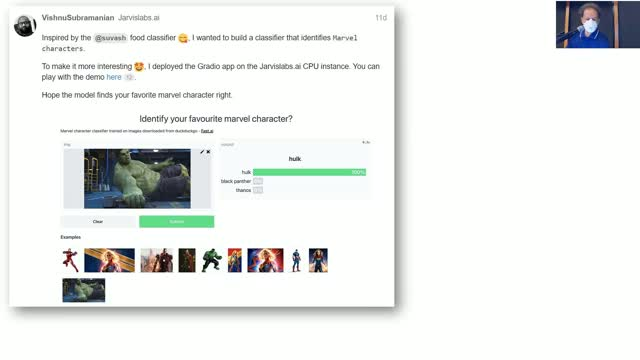

In [ ]:
fetch_frame(VIDEO_ID, PORT, 340)

## Pet Breeds Detector

I'm going to quickly show you a couple of tips before we jump into the mechanics of what's behind a neural network. I was playing during the week with how to make a neural network more accurate, so I created this Pet Detector. This pet detector isn't just predicting dogs or cats, but what breed it is — obviously a much more difficult exercise.

Because I put this out on HuggingFace Spaces, you can download and look at my code. Just click "Files and Versions" on the space — you can find a link on the forum and the course website — and you can download it to your own computer.

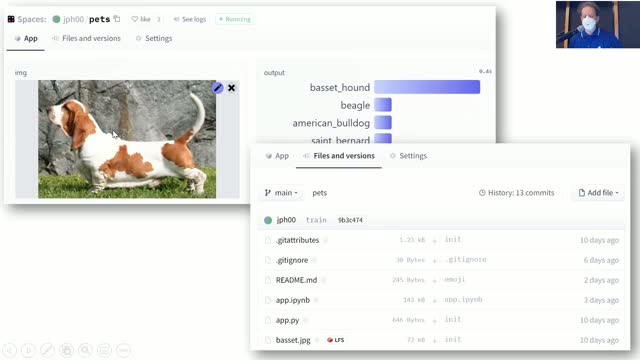

In [ ]:
fetch_frame(VIDEO_ID, PORT, 500)

## Paperspace

Today I'm using a different platform. In the past I've shown you Colab and Kaggle, and we've also looked at doing stuff on your own computer. Paperspace is another website — a bit like Kaggle and Google — but in particular they have a product called Gradient Notebooks, which is, in my opinion, by far the best platform for running this course and for doing experimentation.

Why haven't I been using it the past two weeks? Because I've been waiting for them to build some stuff for us to make it particularly good, and they just finished. I've been using it all week and it's totally amazing.

## JupyterLab

This is what Paperspace looks like — you've got a machine running in the cloud, but the thing that's very special is it's a real computer you're using. It's not like the weird virtual version that Kaggle or Colab has. You can get a full version of Jupyter Lab, or switch to classic Jupyter Notebooks. I'm using Jupyter Lab today because it's a good environment for beginners who aren't familiar with the terminal — you can do everything graphically. There's a file browser, a Git interface, a terminal, and you can create new notebooks.

They have free GPUs, and most importantly two great features: you can pay about eight or nine dollars a month for better GPUs and basically as many hours as you want; and they have persistent storage. With Colab, you have to muck around saving to Google Drive. On Kaggle there isn't really a way of having a persistent environment. On Paperspace, whatever you save is there the next time you come back.

## Training the Pet Classifier

The main thing I wanted you to take away from Lesson Two isn't necessarily all the details of how to use a particular platform, but the key concept. There are really two pieces: the training piece (at the end of which you get a `model.pkl` file), and the deploying piece. Once you've got the trained model, you feed it inputs and it spits out outputs. Because inference happens fast, you generally don't need a GPU for deployment.

I'll show you how I trained my pet classifier. I've got two notebooks: "app" for inference in production, and the training notebook. The training part you've seen before — I create my `ImageDataLoaders`, check the data with `show_batch`, train a ResNet34, and get a 7% error rate. Pretty good.

## Comparison of Image Models

There's a link to a notebook I created (most of the work was done by Ross Wightman) where we can try to improve this by finding a better architecture. There are currently over 500 architectures in the PyTorch Image Models library. We'll learn what they are and how they differ. Broadly, they're all mathematical functions — matrix multiplications and non-linearities such as ReLUs, which we'll talk about today.

Most of the time those details don't matter. What we care about is three things: How fast are they? How much memory do they use? How accurate are they?

We grabbed all the models and created this plot. On the x-axis: seconds per sample (left is faster). On the y-axis: accuracy on ImageNet. Generally, you want things up towards the top-left. We've been mainly working with ResNet — here's ResNet18 (small and fast, great for prototyping) and ResNet34 (widely used, but no longer state of the art). We can look at newer models up here.

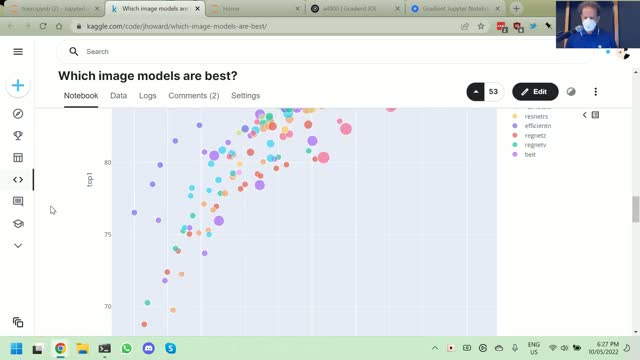

In [ ]:
fetch_frame(VIDEO_ID, PORT, 900)

## Trying New Models: ConvNeXT

The LeVit models seem very accurate and fast, but I tried them on my pets and they didn't work particularly well. So next I tried the ConvNeXT models — one was particularly interesting with super high accuracy at 0.001 seconds inference time.

How do we try it? PyTorch Image Models is in the `timm` module. We call `list_models` with a glob to find all ConvNeXT models, then pass the model name as a string to `vision_learner`. fastai only provides a small number of built-in models, but with timm (`pip install timm`) you get hundreds more.

Training with ConvNeXT: epoch time goes from 20 to 27 seconds (a little slower), but error rate goes from 7.2% down to 5.5% — about a thirty percent improvement. It's been a few years since anything has really beaten ResNet on regular GPUs. If you're not sure what to use, try ConvNeXT.

Model name suffixes: "tiny," "small," "large" indicate size. Names containing `in22ft1k` mean they were trained on ImageNet-22k (about 22,000 categories instead of 1,000), so they're generally more accurate on standard photos of natural objects.

## Categories and Predictions

To turn the trained model into an application, I load the learner and call `predict`, which spits out a list of 37 numbers — the probability of each of the 37 breeds.

What order are they in? fastai always stores category information in the `vocab` object, inside the data loaders — just a list of strings telling us the order. If we zip together the categories and probabilities, we get a dictionary. This was a basset hound, and sure enough — almost certainly a basset hound.

## What's Inside the Model

So what is this magic `model.pkl` file? It's a Learner object with two main things: the pre-processing steps (your DataBlocks or ImageDataLoaders), and the trained model itself. You can grab the trained model with the `.model` attribute.

The model contains lots of layers — it's like a tree, because many layers consist of sub-layers. There's `TimmBody` (most of it), then `Sequential`. Inside `TimmBody` there's `model`, which contains `stem`, `stages`, etc.

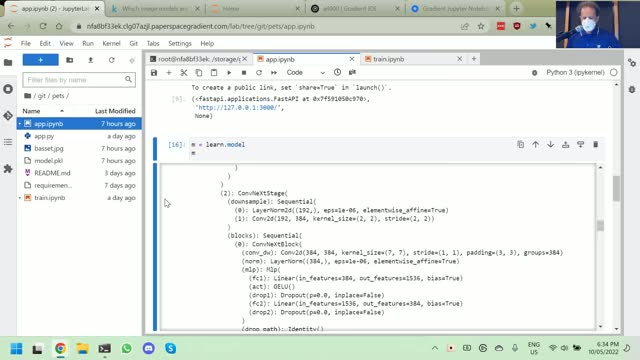

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1295)

## Parameters of a Model

PyTorch has a convenient method called `get_submodule` where we pass in a dotted string navigating the hierarchy. So `"0.model.stem.1"` returns a `LayerNorm2d` layer.

What is this layer? It has some code — a mathematical function — and it has parameters. We can list its parameters: just lots and lots of numbers. Another example: `"0.model.stages.0.blocks.1.mlp.fc1"` — another big bunch of numbers.

What are these numbers, where did they come from, and how can they figure out whether something is a basset hound?

## Fitting Functions to Data

To answer the question of where those parameters come from, we're going to look at a Kaggle notebook: "How does a neural network really work?"

The basic idea is: machine learning models are things that fit functions to data. We start out with a very, very flexible — in fact infinitely flexible — function (a neural network), and we get it to recognize the patterns in the data examples we give it.

Let's do a much simpler example than a neural network — let's do a quadratic. We create a function \(f(x) = 3x^2 + 2x + 1\) and plot it.

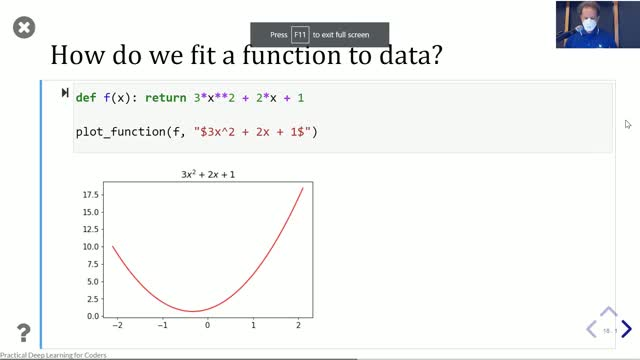

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1490)

We're going to imagine we don't know that's the true function — because it's obviously much simpler than the function that figures out whether an image is a basset hound — and we're going to try to recreate it from data.

It's helpful to have an easier way of creating different quadratics. I've defined a general form with coefficients \(a\), \(b\), and \(c\): at some point \(x\), it's going to be \(ax^2 + bx + c\).

Now we want to create lots of different quadratics to test which one's best. This uses a very helpful Python feature called a **partial application** of a function. Basically I want to fix the values of \(a\), \(b\), and \(c\) to pick a particular quadratic. You call `partial`, pass in the function, and the values you want to fix. So `make_quadratic(3, 2, 1)` creates a quadratic with those coefficients — and the resulting function only needs one input: the value of \(x\), because \(a\), \(b\), and \(c\) are now fixed.

## Fitting by Hand with Sliders

Now I'm going to show some data that matches the shape of this function. But in real life, data is never going to exactly match — it's going to have some noise.

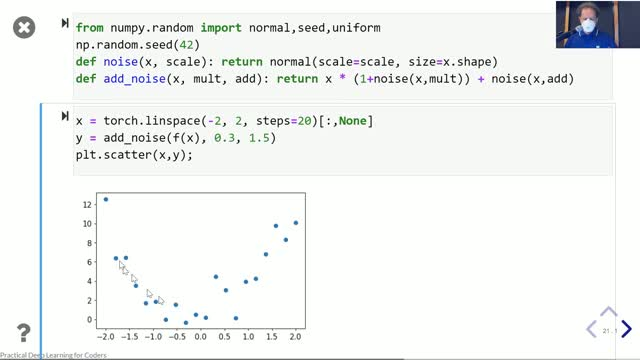

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1670)

So we've got some random data, and the idea is to try to reconstruct the original quadratic — find the one that matches this data. How would we do that?

We create a function called `plot_quadratic` that plots our data as a scatter plot, then plots the quadratic we pass in. There's a very helpful Jupyter feature: the `@interact` decorator. If you add it on top of a function, it gives you nice little sliders.

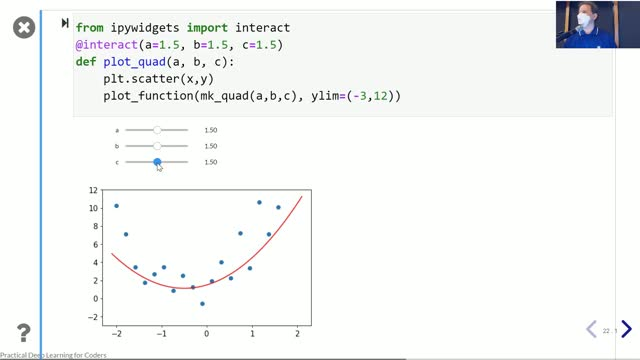

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1780)

Here's a quadratic with coefficients 1.5, 1.5, 1.5 — it doesn't fit particularly well. How do we make it fit better? Take the first slider, try moving it left — that looks worse, more curvy would be better — try the other way. Then do the same for the next slider, and the last one.

You can see what we're doing: pick each coefficient one at a time, try increasing a little bit, try decreasing, find the direction that improves it, and slide it that way. Then go back to the first one and refine further. The result is pretty close to the true answer of 3, 2, 1 — and I wasn't cheating, I promise.

That's basically how those model parameters are created. But the big fancy models often have hundreds of millions of parameters — we don't have time to try a hundred million sliders.

## Loss Functions

We need something better. First, we need a way to measure when a slider move makes things better or worse. If you remember Arthur Samuel's description of machine learning from Chapter One — we need a number that tells us how good our model is. This is called a **loss function**.

There are lots of loss functions you can pick, but perhaps the simplest and most common is **mean squared error**:

\[\text{MSE} = \text{mean}\left((\text{predictions} - \text{actuals})^2\right)\]

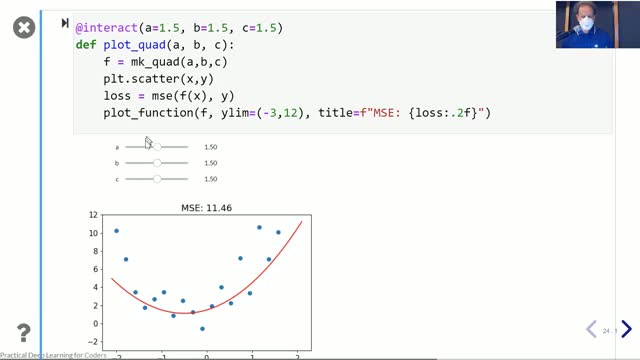

In [ ]:
fetch_frame(VIDEO_ID, PORT, 1950)

If I rerun the same interactive plot but this time calculate and display the MSE, we can do this more rigorously. Starting at a mean squared error of 11.46, we try moving each slider — left or right — and check whether the number goes down. We repeat the process: adjust \(a\), \(b\), and \(c\) one at a time, always moving in the direction that improves the loss. Then go back and refine again.

It's still manual, but at least we don't have to rely on our eyes to judge whether it looks better or worse.

## Automating with Gradient Descent

Finally we're going to automate this. The key question is: for each parameter, when we move it up, does the loss get better? Or when we move it down?

One approach would be to manually try each direction. But there's a much faster way: calculate the **derivative**. The derivative tells you: if you increase the input, does the output increase or decrease, and by how much? That's called the **slope** or the **gradient**.

The good news is PyTorch can automatically calculate it for you. If you went through horrifying months of learning derivative rules in year 11 — don't worry, you don't have to remember any of it.

First, we create a function that takes the coefficients \(a\), \(b\), and \(c\) as inputs (in a list), creates a quadratic with those coefficients (using `*` to spread the parameters), and returns the MSE against our actual data.

If we start with \(a, b, c = 1.5, 1.5, 1.5\), we get MSE of 11.46. It says it's a "tensor" — in PyTorch everything is a tensor. A tensor just means it works with single numbers, vectors (1D), tables (2D), layers of tables (3D), and so forth. This is a single number, but wrapped in PyTorch machinery that can calculate derivatives.

We create our parameters in a rank-1 tensor `[1.5, 1.5, 1.5]` and call `requires_grad_()` to tell PyTorch: please calculate the gradient for these numbers whenever they're used in a calculation.

We pass it to our loss function, getting 11.46 again — but now there's an extra `grad_fn` attribute showing PyTorch knows how to calculate gradients. To trigger the calculation, we call `.backward()` on the result.

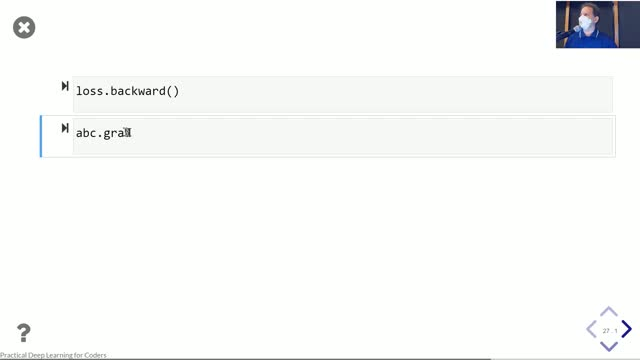

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2310)

When we run `.backward()`, it looks like nothing happens — but it's added a `.grad` attribute to our parameters. This tells us: if I increase \(a\), the loss goes down a lot; if I increase \(b\), the loss goes down a bit less; if I increase \(c\), it goes down a bit.

We want the loss to go down, so we should increase all three — but by how much? Since \(a\)'s gradient is largest, we should adjust it the most.

We update our parameters by subtracting the gradient times a small number (0.01):

```python
with torch.no_grad():
    abc -= abc.grad * 0.01
```

The `torch.no_grad()` context manager is needed because we flagged `abc` to require gradients, but this update step is not our loss — we don't want derivatives of this. This is the standard inner loop of PyTorch training. If you look deep inside fastai source code, you'll see something that looks basically like this.

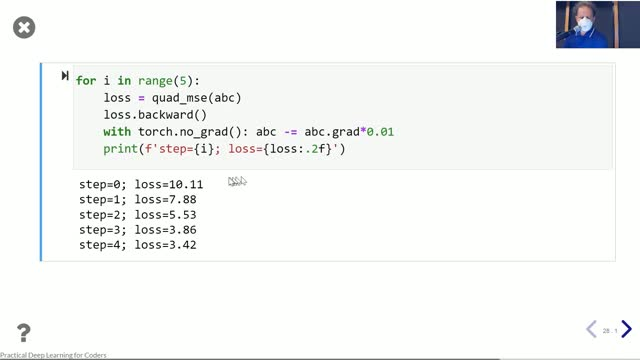

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2510)

We automate it: calculate the loss, call `.backward()`, subtract the gradient times the small number, repeat. After five iterations, the loss keeps improving. The coefficients are heading towards 3, 2, 1.

This is called **optimization**, and this most basic kind is called **gradient descent**. You can see why: we calculate the gradients and then do a descent — trying to decrease the loss.

Believe it or not, that's the entire foundation of how we create those parameters. We need one more piece: what mathematical function are we finding parameters for?

## ReLU: The Rectified Linear Unit

We can't just use quadratics — the relationship between pixels and basset hounds is going to be much more complicated. No problem — it turns out we can create an infinitely flexible function from one tiny thing: the **Rectified Linear Unit** (ReLU).

\[y = \max(0,\; mx + b)\]

The first piece is a linear function with output \(y\), input \(x\), and coefficients \(m\) and \(b\). Then `torch.clip()` takes anything negative and makes it zero.

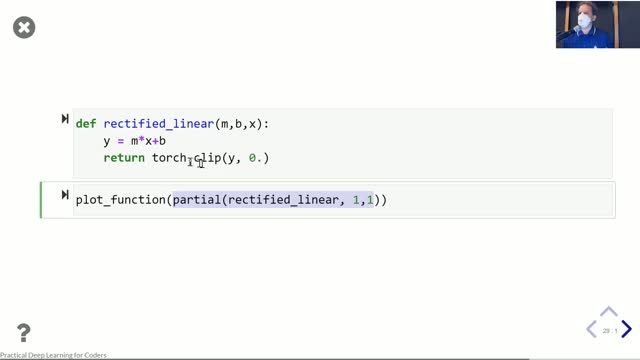

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2670)

If we use `partial` to set \(m = 1\) and \(b = 1\), we get \(y = x + 1\) followed by the clip. As expected: it's a line until it goes below zero, when it becomes a horizontal line at zero.

## Building Complex Functions from ReLUs

Now, why is this interesting? We can take this rectified linear function and create a **double ReLU**, which adds two together:

\[\text{double\_relu}(x) = \max(0,\; m_1 x + b_1) + \max(0,\; m_2 x + b_2)\]

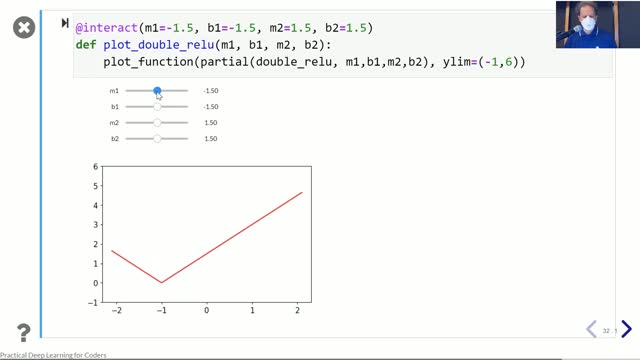

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2760)

What happens is we get a downward slope, then a hook, then an upward slope. Changing \(m_1\) affects the slope of the first part; \(b_1\) changes its position. Similarly \(m_2\) and \(b_2\) control the second part.

This is interesting because we don't have to stop at two — we could add as many ReLUs together as we want. With enough ReLUs, we can match any arbitrarily squiggly function as closely as we want. Imagine an audio waveform of me speaking — with 100 million ReLUs, you could almost exactly match it. And you can add these across as many dimensions as you like — surfaces, 3D, 4D, 5D.

With this incredibly simple foundation you can construct an arbitrarily accurate model. Problem is, you need parameters. Oh, no problem — we know how to get parameters: we use gradient descent.

**Believe it or not, we have just derived deep learning!** Everything from now on is tweaks to make it faster and make it need less data. This is it.

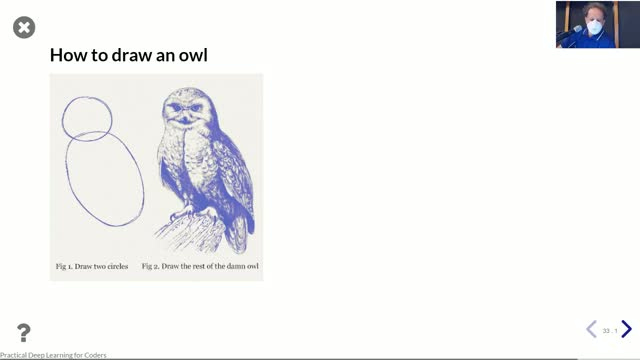

In [ ]:
fetch_frame(VIDEO_ID, PORT, 2900)

I remember a few years ago when I said something like this in a class, somebody on the forum said: "This reminds me of that thing about how to draw an owl." Step one: draw two circles. Step two: draw the rest of the owl.

The thing I have trouble explaining is: when it comes to deep learning, **there is nothing between these two steps**. When you have ReLUs getting added together, gradient descent to optimize the parameters, and samples of inputs and outputs — the computer draws the owl.

We're going to learn about all the other tweaks, and they're all important. But when you're trying to understand something in deep learning, keep reminding yourself: it's using gradient descent to set parameters that make a wiggly function — basically the sum of lots of rectified linear units — match your data.

## Q&A: Finding the Best Model

**Question from Zakia (6 upvotes):** "Is there a way to try out all the different models and automatically find the best performing one?"

Yes, absolutely. Remember `timm.list_models()` returns a list of strings — you can easily add a for loop that tries each architecture. But it's going to take a long time for 500+ models, so I've never done anything like that myself. I'd rather look at the model comparison chart and make a targeted choice.

The vast majority of the time — and this is the biggest mistake I see beginners make — they jump to fancy models from the start of a new project. At the start of a new project I pretty much only use ResNet18, because I want to spend all my time trying things out: different data augmentation, different ways of cleaning the data, different external data. I want to try lots of things as fast as possible.

Trying better architectures is the **very last** thing I do. Once I've got my baseline, I ask: how accurate is it? How fast? Do I need more accuracy? Could I accept a trade-off?

## Q&A: Do I Have Enough Data?

**Question:** "How do I know if I have enough data? What are some signs that indicate my problem needs more data?"

You've got some amount of data. You've built your model, done your best. Is it good enough? You can't know until you've trained the model, but as you've seen, it only takes a few minutes.

My very strong opinion is that the vast majority of projects in industry wait far too long before they train their first model. You want to train your first model on day one with whatever CSV files you can hack together. You might be surprised that the fancy stuff isn't necessary — you already have good enough accuracy. Or quite the opposite — basically no accuracy at all, maybe it's impossible. These are things you want to know at the start, not the end.

We'll learn lots of techniques — in particular **semi-supervised learning**, which lets you get dramatically more out of your data, and **data augmentation**. Often it's easy to get lots of inputs but hard to get labels. For example, in medical imaging it's easy to grab more CT scans, but difficult and expensive to draw segmentation masks. There are ways to take advantage of unlabeled data.

## Q&A: Gradient Units

**Question:** "In the quadratic example, the initial derivatives for \(a\), \(b\), and \(c\) were -10.8, -2.4, etc. What unit are these expressed in? Why don't we adjust parameters by these values directly?"

The unit is: for each increase in \(a\) of one (say from 1.5 to 2.5), the loss would decrease by about 10.9. That's not exactly right because the function is curved — it's the slope at an infinitely small point — but if the slope stayed constant, that's what would happen.

Why not change by these numbers directly? That brings us to a very important concept...

## Learning Rate

Imagine we have some loss function we're fitting. There's theory that says once you get close enough to the optimal value, all functions look like quadratics anyway, so we can draw it as a U-shape.

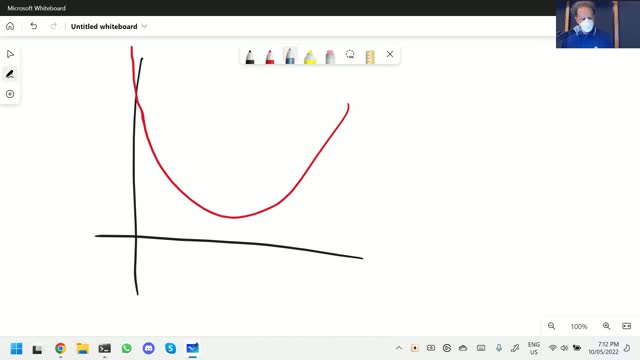

In [ ]:
fetch_frame(VIDEO_ID, PORT, 3440)

Say we're way out on the side, measuring a very steep slope. That seems to suggest we should jump a really long way. So we jump — and we jumped way too far. The slope decreased as we moved along, and that's generally what happens as you approach the optimum.

That's why we multiply the gradient by a small number. That small number has a special name: the **learning rate**. This is an example of a **hyperparameter** — not one of the actual coefficients of your function, but a parameter you use to calculate the parameters. Very meta.

fastai generally picks reasonable defaults, but later in the course we'll learn how to find good learning rates.

If you pick a learning rate that's **too big**, you'll jump too far, overshoot, jump back too far the other way, and diverge. If your model is getting worse during training, your learning rate is probably too big.

If you pick a learning rate that's **too small**, you'll take tiny steps, and the flatter it gets the smaller the steps become — very slow convergence.

Finding the right learning rate is a compromise between speed and the risk of shooting past the optimum.

---

## Matrix Multiplication

Now I want to show you a really important mathematical and computational trick. We want to do a whole bunch of ReLUs — lots of \(mx + b\) operations with lots of variables. For example, every single pixel of an image would be a separate variable. We multiply each by a coefficient, add them all together, do the ReLU, then repeat with a second set of parameters, a third, and so on.

It would be pretty inconvenient to write out 100 million ReLUs, but there's a single mathematical operation that does all of it (except the final replace-negatives-with-zeros): **matrix multiplication**.

When people talk about linear algebra in deep learning, they give the impression you need years of graduate school study. You don't! All you need almost all the time is matrix multiplication, and it couldn't be simpler.

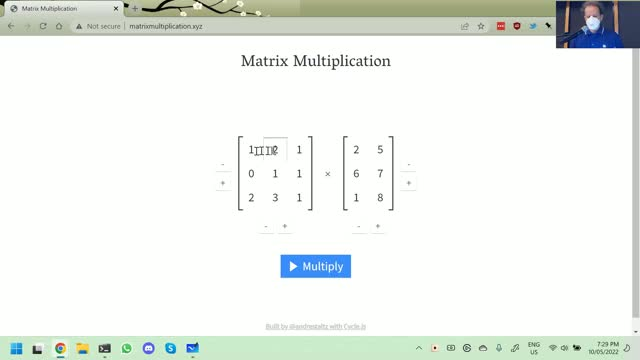

In [ ]:
fetch_frame(VIDEO_ID, PORT, 3730)

There's a really cool site called matrixmultiplication.xyz. The second matrix gets flipped around, and then we do: multiply, add, multiply, add, multiply, add. The first row of the left matrix times the first column of the right matrix gives the top-left result. Keep going for all rows and columns — that's it!

Matrix multiplication is just multiplying things together and adding them up. There's one more step to make it a layer of a neural network: if any results are negative, replace them with zeros.

That's why matrix multiplication is THE critical foundational mathematical operation in basically all of deep learning. The GPUs we use have special **tensor cores** that can multiply two 4×4 matrices together, and they do that lots of times for bigger matrices.

## Building a Regression Model in a Spreadsheet

We're actually going to build a complete machine learning model on real data — in a spreadsheet. fastai has become kind of famous for using spreadsheets to create deep learning models.

I went to Kaggle's Titanic competition — an ongoing competition with 14,000 teams. The data is about who survived and who didn't from the real Titanic disaster. I downloaded the CSV and opened it in Excel, removing a few clearly unimportant columns like passenger name and ID.

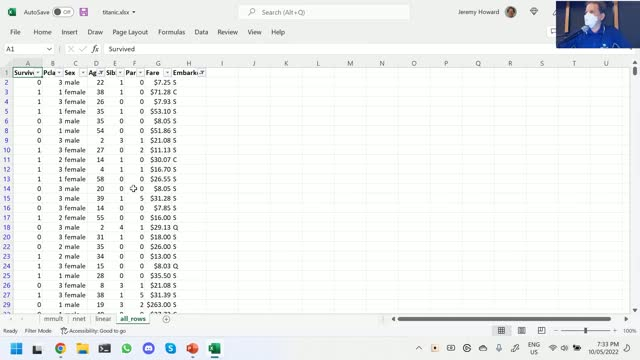

In [ ]:
fetch_frame(VIDEO_ID, PORT, 3950)

Each row is one passenger. The first column is the dependent variable: did they survive? The remaining columns are: class (first, second, or third), sex, age, number of siblings, number of parents/children, fare, and embarkation city (Cherbourg, Queenstown, Southampton). I removed rows with missing age or embarkation data, which left nearly all the data.

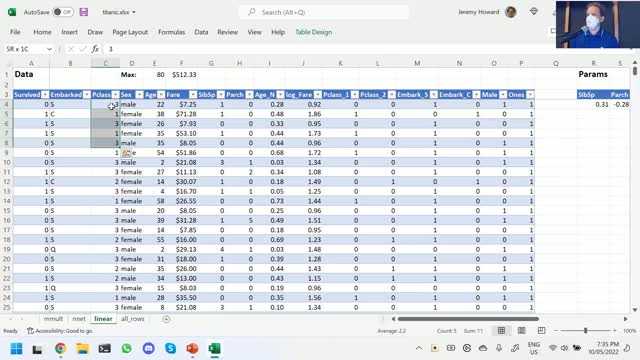

In [ ]:
fetch_frame(VIDEO_ID, PORT, 4100)

How do you multiply the word "Male" by a coefficient? You can't. So I converted everything to numbers. Male/Female became `isMale` (1 or 0, using an IF statement). Same for Embarked: one column for Southampton, one for Cherbourg.

Passenger class (1, 2, 3) is a number but not really a continuous measurement — they're different levels. So I created **binary categorical variables** (dummy variables): "is first class?" and "is second class?"

I also noticed that fares and ages, being much larger than 0-1, would dominate everything else. So I **normalized** the data by dividing by the maximum. For Fare specifically — since money has a few very big numbers and lots of small ones — taking the **log** gives a much more evenly distributed variable.

I created random coefficients (RAND minus 0.5 for small numbers around zero) and used SUMPRODUCT to multiply each feature by its coefficient and add them together.

One trick: in a linear equation \(y = mx + b\), there's a constant term at the end. Instead of handling it specially, I added a column of data containing the number 1 for every row. That parameter becomes the constant term — everybody does this in machine learning.

The loss for each row is \((\text{prediction} - \text{survived})^2\), averaged across all rows. Then I used Excel's **Solver** — which is a gradient descent optimizer built into Excel! — to minimize the loss. It went from about 1.03 down to 0.1.

Looking at predictions: the first passenger is predicted exactly correctly — "didn't survive" and we predicted "wouldn't survive." But you can start to see issues — sometimes predicting less than zero or more than one. Wouldn't it be cool if we could constrain it to between zero and one? That's an example of things we'll learn about.

## Building a Neural Network in Excel

That's not deep learning yet — just a regression. To make it a neural net, we need to do it multiple times. So now I have two sets of coefficients with random numbers.

The first SUMPRODUCT uses the first set of coefficients; the second uses the second set. But there's no point adding two linear functions together — you'd just get another linear function. We need the wiggles! That's why we do the ReLU.

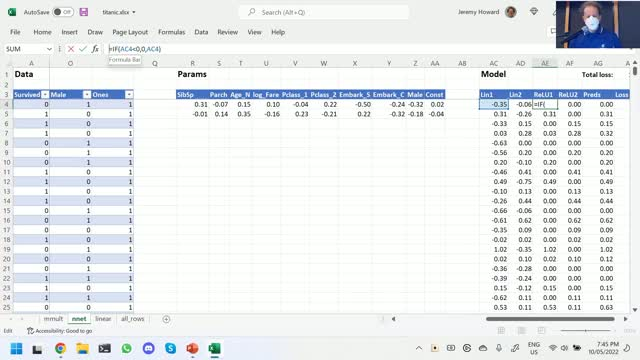

In [ ]:
fetch_frame(VIDEO_ID, PORT, 4630)

In Excel, ReLU is: `IF(number < 0, 0, number)`. Replace negatives with zeros. Then we add the two ReLU outputs together for our prediction. The loss is the same: survived minus prediction, squared, averaged.

Solving: **0.08** for our deep learning model versus **0.1** for our regression — a bit better. So we've created our first deep learning neural network from scratch, in Microsoft Excel, everybody's favorite artificial intelligence tool.

## Matrix Multiplication Makes It Faster

That was a bit slow and painful. It's faster if we use matrix multiplication. This next spreadsheet is exactly the same but uses MMULT.

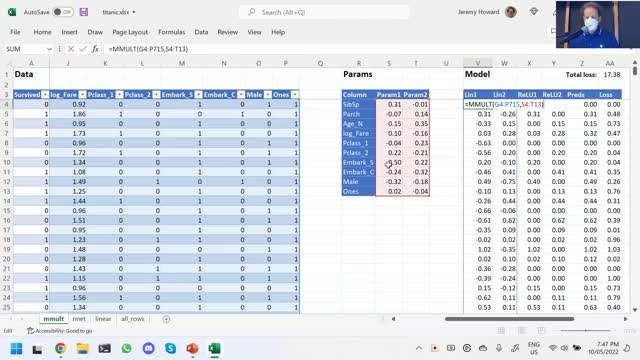

In [ ]:
fetch_frame(VIDEO_ID, PORT, 4780)

The key difference is the parameters have been transposed — rows and columns are swapped. Other than that, the entire computation is a single MMULT function. Optimizing gives the same number: 0.08.

Matrix multiplication takes a surprisingly long time to get an intuitive feel for as a single mathematical operation. I still find it helpful to remind myself: it's just doing SUMPRODUCTs and additions.

## Chapter 4 Warning

The chapter of the book that goes with this lesson is Chapter Four — and Chapter Four is where we lose the most people, because it's hard. Part of the reason is I couldn't put the spreadsheet into a book. We're teaching it very differently in the course.

If you've tried to read the book and been a bit disheartened — try following through the spreadsheet instead. Maybe create your own version in Numbers or Google Sheets, or try doing it from scratch in Python if you want to really test yourself.

## Q&A: Dummy Variables

**Question from Victor Guerrero:** "Why is there no `Pclass_3` column? Is it because if `Pclass_1` is zero and `Pclass_2` is zero, then `Pclass_3` must be one?"

Yes! That's exactly the reason. There's no need to tell the computer about things it can figure out for itself. These are called **dummy variables**. A categorical variable with \(n\) levels needs \(n - 1\) columns.

## Natural Language Processing Preview

Next lesson we'll look at **natural language processing** (NLP). So far we've looked at computer vision and tabular data (spreadsheet-type data). NLP is about taking text data and making predictions.

Some examples of NLP applications: **sentiment analysis** (is this review positive or negative?), author identification, legal discovery (is this document in scope?), document organization, email triaging (which department? urgent or not?).

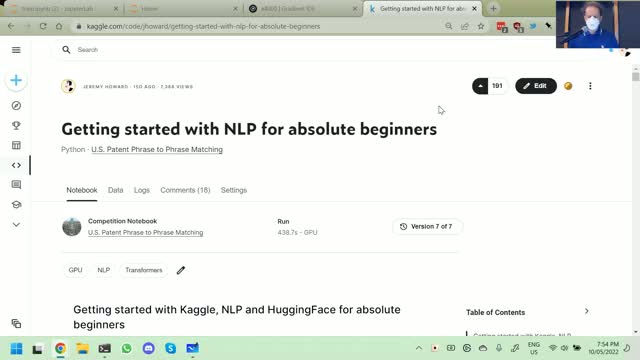

In [ ]:
fetch_frame(VIDEO_ID, PORT, 5060)

## HuggingFace Transformers

For NLP, we're going to use the **HuggingFace Transformers** library rather than fastai. Two reasons: first, it's helpful to see how things are done in more than one library. Second, HuggingFace Transformers doesn't have the same high-level API that fastai has, so you have to do more stuff manually — at this point in the course, we'll intentionally use a less user-friendly library to see what extra steps are involved.

That said, it's a particularly good library with great models and techniques — not surprising since they've hired lots of fast.ai alumni.

If your language is not English and not well represented in NLP resources — that's an opportunity, not a problem. The fastai community has been fantastic at building NLP resources for underrepresented languages. The first Farsi NLP resource was created by a student from the very first fast.ai course, and some of the best Indic language resources have come from fastai alumni.

## Homework

The data we'll work with next week is from a Kaggle competition trying to figure out, using patents, whether two concepts refer to the same thing — represented as English text. It's a classification task: the document is "text one + text two" and the category is "similar or not-similar," scored from 0 to 1.

Before the next lesson, if you've got time, take a look at the "Getting Started with NLP for Absolute Beginners" notebook and the data. We're going to go through it step by step, and we'll also discuss the important topics of **validation sets** and **metrics** — two of the most important topics in machine learning.

Thanks, everybody. See you next week!